In [ ]:
!pip install transformers seaborn nltk wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from transformers import pipeline
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving comments_cleaned.csv to comments_cleaned (1).csv


In [ ]:
df = pd.read_csv("comments_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7488, 9)


,Unnamed: 0,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [ ]:
df = df[['comment']]

df = df.dropna()

df.head()

,comment
0,unde at dolorem
1,quae ea ducimus
2,alias a voluptatum
3,facere suscipit sunt
4,totam eligendi quaerat


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)

    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['clean_comment'] = df['comment'].apply(clean_text)

In [ ]:
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
df['sentiment'] = df['clean_comment'].apply(
    lambda x: classifier(x[:512])[0]['label']
)

In [ ]:
df['sentiment'] = df['sentiment'].str.lower()

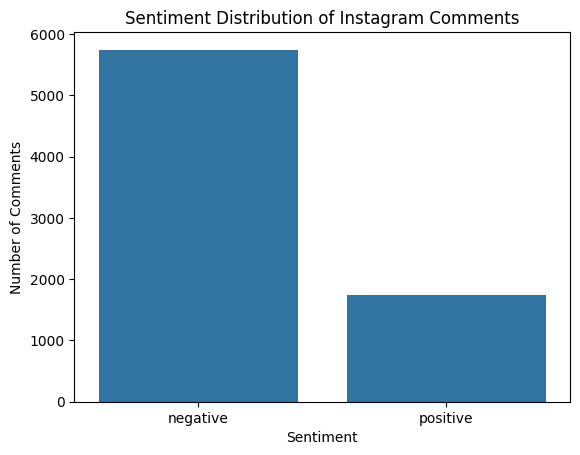

In [ ]:
#Sentiment Distribution Graph
plt.figure()

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution of Instagram Comments")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

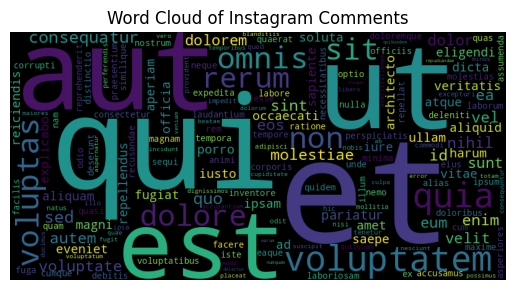

In [ ]:
#Word Cloud Visualization
text = " ".join(df['clean_comment'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Instagram Comments")

plt.show()

In [ ]:
#Encode Sentiment for Models
df['sentiment_label'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [ ]:
#Save Cleaned Dataset
df.to_csv("instagram_sentiment_dataset.csv", index=False)

In [ ]:
files.download("instagram_sentiment_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>